# Notebook 21 -- Wu 2003 Control Structure Verification

This notebook is the nb21 checkpoint from
[`../project_wu2003_sbi.md`](../project_wu2003_sbi.md): verify the
control-structure surface before stochastic data generation.

The full plan distinguishes two plant-wide structures:

- **S-A**: composition analysers available (`x_D`, later `x_B`) and richer
  column information.
- **S-B**: conventional measurements only; no online composition analyser.

The current deterministic layer does not yet implement separate S-A/S-B
reflux/reboiler controller loops. It does expose the reactor PI controller and
QSS column outputs. Therefore nb21 treats S-A and S-B as **measurement views**
over the same trajectories:

- S-A view: `[T_r, T_j, Q_j, x_D, T_reb, Q_reb, F_R/F_R_nom, F_B/F_B_nom]`
- S-B view: `[T_r, T_j, Q_j, T_reb, Q_reb, F_R/F_R_nom, F_B/F_B_nom]`

The notebook checks W1-W4 closed-loop trajectories and compares selected
faults against a fixed-cooling open-loop proxy. That is enough to verify the
information asymmetry needed before nb22, while clearly marking the remaining
plant-wide controller work.


## 1. Imports and helpers

The fixed-cooling open-loop proxy clamps jacket duty at `QJ_NOM`. It is a
diagnostic comparison, not a separate published Wu controller.


In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL,
    NOMINAL_INLET,
    NOMINAL_THETA,
    NOMINAL_Y0,
    QJ_NOM,
    T_SP,
    X_B_NOM,
    X_D_NOM,
    extract_observations,
    simulate_to_steady_state,
    simulate_trajectory,
)
from cstr_sbi.recycle.scenarios import SCENARIO_CONFIGS

pd.set_option("display.precision", 5)

RAW_COLUMNS = ["z_A", "T_r", "T_j", "Q_j", "x_D", "x_B", "F_R_norm", "T_reb", "Q_reb", "F_B_norm"]
RAW_INDEX = {name: i for i, name in enumerate(RAW_COLUMNS)}
SA_COLUMNS = ["T_r", "T_j", "Q_j", "x_D", "T_reb", "Q_reb", "F_R_norm", "F_B_norm"]
SB_COLUMNS = ["T_r", "T_j", "Q_j", "T_reb", "Q_reb", "F_R_norm", "F_B_norm"]
SA_INDICES = [RAW_INDEX[name] for name in SA_COLUMNS]
SB_INDICES = [RAW_INDEX[name] for name in SB_COLUMNS]

CTRL_OPEN_PROXY = NOMINAL_CTRL.at[0].set(0.0).at[4].set(QJ_NOM).at[5].set(QJ_NOM)

print("JAX devices:", jax.devices())
print("Raw channels:", RAW_COLUMNS)
print("S-A channels:", SA_COLUMNS)
print("S-B channels:", SB_COLUMNS)
print(f"Fixed-cooling open-loop proxy: Q_j = {QJ_NOM:.3e} Btu/h")


JAX devices: [CpuDevice(id=0)]
Raw channels: ['z_A', 'T_r', 'T_j', 'Q_j', 'x_D', 'x_B', 'F_R_norm', 'T_reb', 'Q_reb', 'F_B_norm']
S-A channels: ['T_r', 'T_j', 'Q_j', 'x_D', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm']
S-B channels: ['T_r', 'T_j', 'Q_j', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm']
Fixed-cooling open-loop proxy: Q_j = 9.351e+06 Btu/h


## 2. Scenario subset for nb21

The plan calls for W1-W4 in nb21: healthy operation, catalyst decay, reactor
jacket fouling, and column tray-efficiency loss.


In [2]:
SCENARIO_KEYS = ["W1_healthy", "W2_cat_decay", "W3_rxr_fouling", "W4_col_tray_eff"]

scenario_df = pd.DataFrame([
    {
        "key": key,
        "id": SCENARIO_CONFIGS[key].id,
        "name": SCENARIO_CONFIGS[key].name,
        "alpha": SCENARIO_CONFIGS[key].alpha,
        "beta_r": SCENARIO_CONFIGS[key].beta_r,
        "eta_col": SCENARIO_CONFIGS[key].eta_col,
        "xi_reb": SCENARIO_CONFIGS[key].xi_reb,
        "z_A0_eff": SCENARIO_CONFIGS[key].z_A0_eff,
        "description": SCENARIO_CONFIGS[key].description,
    }
    for key in SCENARIO_KEYS
]).set_index("key")

scenario_df


,id,name,alpha,beta_r,eta_col,xi_reb,z_A0_eff,description
key,,,,,,,,
W1_healthy,1,W1_healthy,1.00,1.00,1.0,1.0,0.9,"Healthy plant, all parameters nominal."
W2_cat_decay,2,W2_cat_decay,0.65,1.00,1.0,1.0,0.9,Severe catalyst decay (alpha=0.65). Reaction r...
W3_rxr_fouling,3,W3_rxr_fouling,1.00,0.65,1.0,1.0,0.9,Severe CSTR jacket fouling (beta_r=0.65). UA r...
W4_col_tray_eff,4,W4_col_tray_eff,1.00,1.00,0.7,1.0,0.9,Column tray efficiency loss (eta_col=0.70). Se...


## 3. Generate deterministic trajectories

Each scenario is warm-started from the nominal closed-loop steady state. We
then integrate the same fault under closed-loop and fixed-cooling open-loop
proxy modes.


In [3]:
y_nom_ss = simulate_to_steady_state(
    NOMINAL_THETA,
    NOMINAL_INLET,
    NOMINAL_CTRL,
    NOMINAL_Y0,
    t_final=200.0,
)


def run_case(scenario_key, mode, t_final=50.0, n_save=301):
    scenario = SCENARIO_CONFIGS[scenario_key]
    theta = scenario.theta()
    ctrl = NOMINAL_CTRL if mode == "closed_loop" else CTRL_OPEN_PROXY
    ts, ys = simulate_trajectory(
        theta,
        NOMINAL_INLET,
        ctrl,
        y_nom_ss,
        t_final=t_final,
        n_save=n_save,
    )
    obs = extract_observations(ys, theta, ctrl)
    return {
        "scenario_key": scenario_key,
        "scenario_name": scenario.name,
        "mode": mode,
        "t": np.asarray(ts),
        "obs": np.asarray(obs),
    }


cases = {}
for key in SCENARIO_KEYS:
    for mode in ["closed_loop", "open_loop_proxy"]:
        cases[(key, mode)] = run_case(key, mode)

print(f"Generated {len(cases)} deterministic trajectories")
print(f"Observation shape: {cases[(SCENARIO_KEYS[0], 'closed_loop')]['obs'].shape}")


Generated 8 deterministic trajectories
Observation shape: (301, 10)


## 4. S-A and S-B measurement views

S-A includes the column composition analyser channels. S-B removes those
channels, leaving the conventional reactor/cooling/recycle measurements in the
currently implemented layer.


In [4]:
def as_frame(case, structure):
    obs = case["obs"]
    if structure == "S-A":
        data = obs[:, SA_INDICES]
        columns = SA_COLUMNS
    elif structure == "S-B":
        data = obs[:, SB_INDICES]
        columns = SB_COLUMNS
    else:
        raise ValueError(structure)
    frame = pd.DataFrame(data, columns=columns)
    frame.insert(0, "time_h", case["t"])
    return frame


print(f"S-A channels: {len(SA_COLUMNS)}")
print(f"S-B channels: {len(SB_COLUMNS)}")
display(as_frame(cases[("W1_healthy", "closed_loop")], "S-A").head())
display(as_frame(cases[("W1_healthy", "closed_loop")], "S-B").head())


S-A channels: 8
S-B channels: 7


,time_h,T_r,T_j,Q_j,x_D,T_reb,Q_reb,F_R_norm,F_B_norm
0,0.00000,342.27863,331.35123,9491172.0,0.97558,372.00546,12011361.0,1.00182,1.0
1,0.16667,342.27878,331.35220,9492392.0,0.97558,372.00546,12011361.0,1.00182,1.0
2,0.33333,342.27881,331.35239,9492637.0,0.97558,372.00546,12011361.0,1.00182,1.0
3,0.50000,342.27881,331.35394,9492637.0,0.97558,372.00546,12011361.0,1.00182,1.0
4,0.66667,342.27859,331.35239,9490928.0,0.97558,372.00546,12011361.0,1.00182,1.0


,time_h,T_r,T_j,Q_j,T_reb,Q_reb,F_R_norm,F_B_norm
0,0.00000,342.27863,331.35123,9491172.0,372.00546,12011361.0,1.00182,1.0
1,0.16667,342.27878,331.35220,9492392.0,372.00546,12011361.0,1.00182,1.0
2,0.33333,342.27881,331.35239,9492637.0,372.00546,12011361.0,1.00182,1.0
3,0.50000,342.27881,331.35394,9492637.0,372.00546,12011361.0,1.00182,1.0
4,0.66667,342.27859,331.35239,9490928.0,372.00546,12011361.0,1.00182,1.0


## 5. W1-W4 closed-loop trajectories

The expected qualitative behavior is: W2 raises recycle flow, W3 masks the
reactor-temperature fault signature while moving `Q_j`, and W4 is directly
visible in the S-A composition channels.


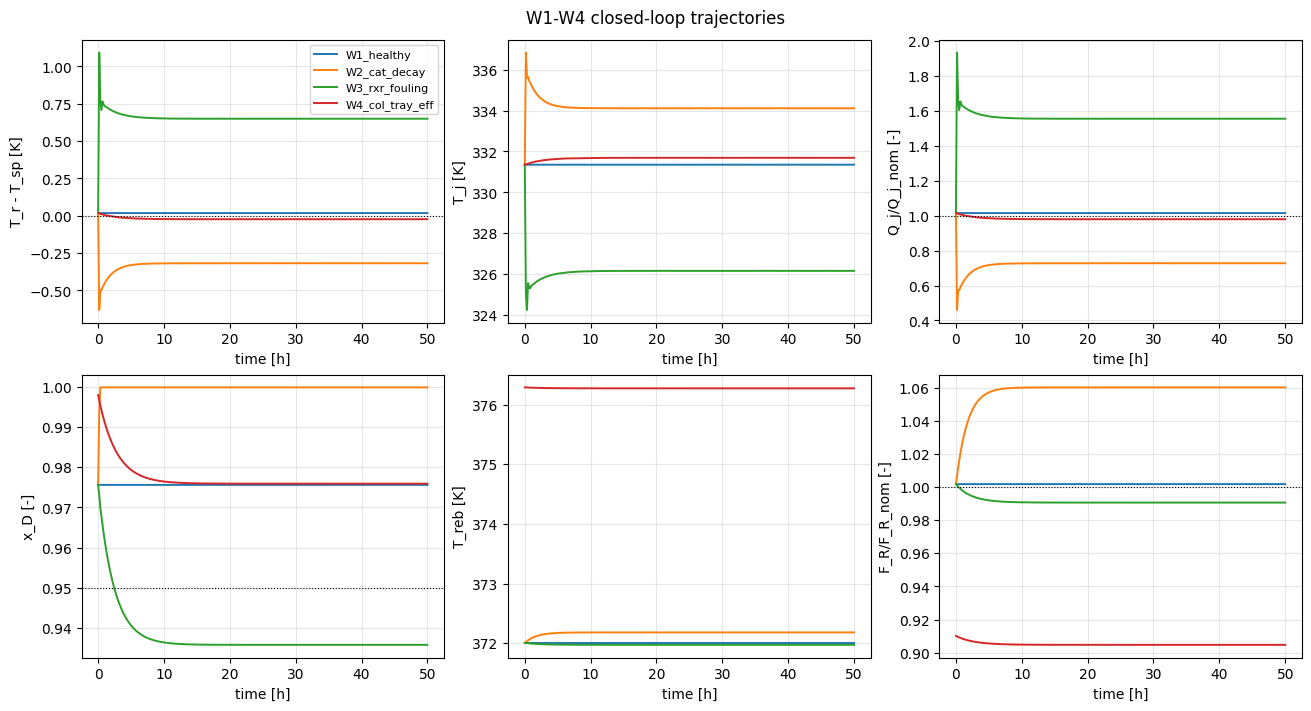

In [5]:
plot_specs = [
    ("T_r - T_sp [K]", lambda obs: obs[:, 1] - T_SP),
    ("T_j [K]", lambda obs: obs[:, 2]),
    ("Q_j/Q_j_nom [-]", lambda obs: obs[:, 3] / QJ_NOM),
    ("x_D [-]", lambda obs: obs[:, 4]),
    ("T_reb [K]", lambda obs: obs[:, 7]),
    ("F_R/F_R_nom [-]", lambda obs: obs[:, 6]),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for key in SCENARIO_KEYS:
    case = cases[(key, "closed_loop")]
    for ax, (ylabel, getter) in zip(axes.ravel(), plot_specs):
        ax.plot(case["t"], getter(case["obs"]), lw=1.4, label=case["scenario_name"])

for ax, (ylabel, _) in zip(axes.ravel(), plot_specs):
    ax.set_xlabel("time [h]")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
axes[0, 0].axhline(0.0, color="k", ls=":", lw=0.8)
axes[0, 2].axhline(1.0, color="k", ls=":", lw=0.8)
axes[1, 0].axhline(X_D_NOM, color="k", ls=":", lw=0.8)
axes[1, 2].axhline(1.0, color="k", ls=":", lw=0.8)
axes[0, 0].legend(fontsize=8)
fig.suptitle("W1-W4 closed-loop trajectories", fontsize=12)
plt.show()


## 6. Closed-loop vs open-loop proxy comparison

The comparison focuses on W2 and W3. It mirrors the original closed-loop
identifiability story: feedback masks `T_r`, while compensation appears in
controller and jacket channels.


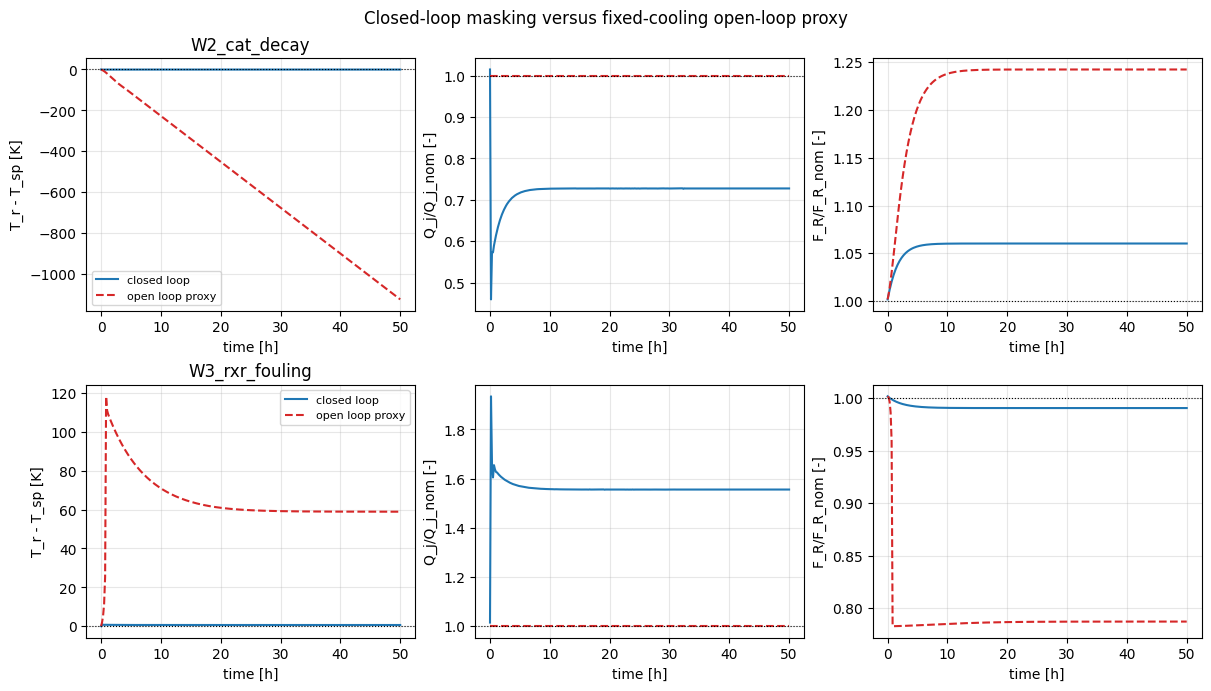

In [6]:
compare_keys = ["W2_cat_decay", "W3_rxr_fouling"]
fig, axes = plt.subplots(len(compare_keys), 3, figsize=(12, 6.8), constrained_layout=True)

for row, key in enumerate(compare_keys):
    for mode, color, ls in [("closed_loop", "C0", "-"), ("open_loop_proxy", "C3", "--")]:
        case = cases[(key, mode)]
        obs = case["obs"]
        label = mode.replace("_", " ")
        axes[row, 0].plot(case["t"], obs[:, 1] - T_SP, color=color, ls=ls, lw=1.5, label=label)
        axes[row, 1].plot(case["t"], obs[:, 3] / QJ_NOM, color=color, ls=ls, lw=1.5, label=label)
        axes[row, 2].plot(case["t"], obs[:, 6], color=color, ls=ls, lw=1.5, label=label)
    axes[row, 0].set_title(SCENARIO_CONFIGS[key].name)
    axes[row, 0].set_ylabel("T_r - T_sp [K]")
    axes[row, 1].set_ylabel("Q_j/Q_j_nom [-]")
    axes[row, 2].set_ylabel("F_R/F_R_nom [-]")
    axes[row, 0].axhline(0.0, color="k", ls=":", lw=0.8)
    axes[row, 1].axhline(1.0, color="k", ls=":", lw=0.8)
    axes[row, 2].axhline(1.0, color="k", ls=":", lw=0.8)
    axes[row, 0].legend(fontsize=8)

for ax in axes.ravel():
    ax.set_xlabel("time [h]")
    ax.grid(alpha=0.3)
fig.suptitle("Closed-loop masking versus fixed-cooling open-loop proxy", fontsize=12)
plt.show()


## 7. Final-state metrics

These metrics feed the automated nb21 acceptance table.


In [7]:
rows = []
for key in SCENARIO_KEYS:
    for mode in ["closed_loop", "open_loop_proxy"]:
        case = cases[(key, mode)]
        obs0 = case["obs"][0]
        obsf = case["obs"][-1]
        rows.append({
            "scenario": key,
            "mode": mode,
            "T_error_final_K": obsf[1] - T_SP,
            "T_error_max_abs_K": np.max(np.abs(case["obs"][:, 1] - T_SP)),
            "Qj_ratio_initial": obs0[3] / QJ_NOM,
            "Qj_ratio_final": obsf[3] / QJ_NOM,
            "xD_initial": obs0[4],
            "xD_final": obsf[4],
            "xB_initial": obs0[5],
            "xB_final": obsf[5],
            "FR_ratio_initial": obs0[6],
            "FR_ratio_final": obsf[6],
            "FR_change_pct": 100.0 * (obsf[6] / obs0[6] - 1.0),
            "Treb_initial": obs0[7],
            "Treb_final": obsf[7],
            "Qreb_ratio_initial": obs0[8] / obs0[8],
            "Qreb_ratio_final": obsf[8] / obs0[8],
            "FB_ratio_initial": obs0[9],
            "FB_ratio_final": obsf[9],
        })

metrics = pd.DataFrame(rows)
metrics


,scenario,mode,T_error_final_K,T_error_max_abs_K,Qj_ratio_initial,Qj_ratio_final,xD_initial,xD_final,xB_initial,xB_final,FR_ratio_initial,FR_ratio_final,FR_change_pct,Treb_initial,Treb_final,Qreb_ratio_initial,Qreb_ratio_final,FB_ratio_initial,FB_ratio_final
0,W1_healthy,closed_loop,0.01764,0.01788,1.01499,1.01510,0.97558,0.97558,0.0105,0.0105,1.00182,1.00182,-0.00001,372.00546,372.00546,1.0,1.00000,1.0,1.0
1,W1_healthy,open_loop_proxy,-897.93433,897.93433,1.00000,1.00000,0.97558,0.99980,0.0105,0.0105,1.00182,1.24222,23.99716,372.00546,372.72668,1.0,1.12514,1.0,1.0
2,W2_cat_decay,closed_loop,-0.31833,0.63162,1.01499,0.72765,0.97558,0.99980,0.0105,0.0105,1.00182,1.06026,5.83369,372.00546,372.18079,1.0,1.03042,1.0,1.0
3,W2_cat_decay,open_loop_proxy,-1124.80103,1124.80103,1.00000,1.00000,0.97558,0.99980,0.0105,0.0105,1.00182,1.24224,23.99858,372.00546,372.72672,1.0,1.12515,1.0,1.0
4,W3_rxr_fouling,closed_loop,0.64954,1.09250,1.01499,1.55573,0.97558,0.93585,0.0105,0.0105,1.00182,0.99065,-1.11431,372.00546,371.97195,1.0,0.99419,1.0,1.0
5,W3_rxr_fouling,open_loop_proxy,58.92386,118.25800,1.00000,1.00000,0.97558,0.01528,0.0105,0.0105,1.00182,0.78737,-21.40602,372.00546,371.36209,1.0,0.88837,1.0,1.0
6,W4_col_tray_eff,closed_loop,-0.02341,0.02374,1.01499,0.97998,0.99789,0.97588,0.0345,0.0345,0.91007,0.90469,-0.59099,376.29019,376.27405,1.0,0.99706,1.0,1.0
7,W4_col_tray_eff,open_loop_proxy,-903.58844,903.58844,1.00000,1.00000,0.99789,0.99980,0.0345,0.0345,0.91007,1.12544,23.66543,376.29019,376.93631,1.0,1.11773,1.0,1.0


## 8. Automated nb21 acceptance check

This check verifies the nb21 scope against the project plan while preserving
the current implementation boundary: S-A/S-B are measurement views here; the
full controller-loop split belongs to a later physics extension.


In [8]:
def verdict(condition):
    return "PASS" if bool(condition) else "FAIL"


def metric_row(scenario, mode):
    return metrics[(metrics["scenario"] == scenario) & (metrics["mode"] == mode)].iloc[0]


w1_cl = metric_row("W1_healthy", "closed_loop")
w2_cl = metric_row("W2_cat_decay", "closed_loop")
w3_cl = metric_row("W3_rxr_fouling", "closed_loop")
w4_cl = metric_row("W4_col_tray_eff", "closed_loop")
w3_ol = metric_row("W3_rxr_fouling", "open_loop_proxy")

acceptance = pd.DataFrame([
    {
        "check": "W1-W4 trajectories generated",
        "expected": "4 scenarios x 2 modes",
        "observed": f"{len(cases)} trajectories",
        "status": verdict(len(cases) == 8),
    },
    {
        "check": "S-A/S-B measurement asymmetry",
        "expected": "S-A has x_D/x_B; S-B removes them",
        "observed": f"S-A={len(SA_COLUMNS)} channels, S-B={len(SB_COLUMNS)} channels",
        "status": verdict("x_D" in SA_COLUMNS and "x_D" not in SB_COLUMNS and len(SA_COLUMNS) == 8 and len(SB_COLUMNS) == 7),
    },
    {
        "check": "W1 closed-loop regulation",
        "expected": "healthy T_r near setpoint",
        "observed": f"max |T_r-T_sp|={w1_cl['T_error_max_abs_K']:.3f} K",
        "status": verdict(w1_cl["T_error_max_abs_K"] < 0.5),
    },
    {
        "check": "W2 catalyst snowball under closed-loop",
        "expected": "F_R increases",
        "observed": f"F_R change={w2_cl['FR_change_pct']:.2f}%",
        "status": verdict(w2_cl["FR_change_pct"] > 5.0),
    },
    {
        "check": "W3 temperature masking under closed-loop",
        "expected": "T_r nearly regulated despite fouling",
        "observed": f"max |T_r-T_sp|={w3_cl['T_error_max_abs_K']:.3f} K",
        "status": verdict(w3_cl["T_error_max_abs_K"] < 2.0),
    },
    {
        "check": "W3 compensation channel moves",
        "expected": "Q_j changes under fouling",
        "observed": f"Q_j ratio final={w3_cl['Qj_ratio_final']:.3f}",
        "status": verdict(abs(w3_cl["Qj_ratio_final"] - w3_cl["Qj_ratio_initial"]) > 0.05),
    },
    {
        "check": "W4 column fault visible to S-A",
        "expected": "x_D or reboiler proxies shift when eta_col drops",
        "observed": f"x_D={w4_cl['xD_final']:.3f}, T_reb={w4_cl['Treb_final']:.2f} K, Q_reb ratio={w4_cl['Qreb_ratio_final']:.3f}",
        "status": verdict(abs(w4_cl["xD_final"] - w1_cl["xD_final"]) > 0.01 or abs(w4_cl["Treb_final"] - w1_cl["Treb_final"]) > 1.0 or abs(w4_cl["Qreb_ratio_final"] - w1_cl["Qreb_ratio_final"]) > 0.05),
    },
    {
        "check": "closed-loop vs open-loop contrast",
        "expected": "open-loop proxy has larger W3 T excursion than closed-loop",
        "observed": f"W3 max |T|: CL={w3_cl['T_error_max_abs_K']:.2f} K, OL={w3_ol['T_error_max_abs_K']:.2f} K",
        "status": verdict(w3_ol["T_error_max_abs_K"] > w3_cl["T_error_max_abs_K"]),
    },
])

acceptance


,check,expected,observed,status
0,W1-W4 trajectories generated,4 scenarios x 2 modes,8 trajectories,PASS
1,S-A/S-B measurement asymmetry,S-A has x_D/x_B; S-B removes them,"S-A=8 channels, S-B=7 channels",PASS
2,W1 closed-loop regulation,healthy T_r near setpoint,max |T_r-T_sp|=0.018 K,PASS
3,W2 catalyst snowball under closed-loop,F_R increases,F_R change=5.83%,PASS
4,W3 temperature masking under closed-loop,T_r nearly regulated despite fouling,max |T_r-T_sp|=1.092 K,PASS
5,W3 compensation channel moves,Q_j changes under fouling,Q_j ratio final=1.556,PASS
6,W4 column fault visible to S-A,x_D or reboiler proxies shift when eta_col drops,"x_D=0.976, T_reb=376.27 K, Q_reb ratio=0.997",PASS
7,closed-loop vs open-loop contrast,open-loop proxy has larger W3 T excursion than...,"W3 max |T|: CL=1.09 K, OL=118.26 K",PASS


## 9. Interpretation

The current implementation passes the nb21 measurement-structure verification:
W1-W4 deterministic trajectories are generated, S-A and S-B have different
information sets, catalyst decay produces recycle buildup, and reactor jacket
fouling is masked in `T_r` while compensation appears in `Q_j`.

This notebook deliberately does **not** claim that the full Wu 2003 S-A and S-B
plant-wide control structures are complete. The missing next layer is the
separate column-control implementation: S-A composition loops for `x_D`/`x_B`
and S-B conventional loops using reboiler-temperature/reflux-ratio signals.
Those loops should be added before nb22 if the generated dataset is intended to
represent the full 61-D versus 55-D S-A/S-B SBI comparison.
